In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data.csv')

# Struktura podataka

In [3]:
# Oblik i prvih 5 redova

print("Oblik", df.shape)
df.head()

Oblik (11500, 180)


,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


Ukupno 11500 instanci u skupu.

U skupu podataka se nalaze izmerene vrednosti EEG signala za 500 ispitanika u trajanju od 23.6 sekundi. <br> Jedna instanca skupa predstavlja izmerene vrednosti EEG signala u trajanju od jedne sekunde, <br> za jednog ispitanika, sto daje ukupno 11 500 instanci u skupu (500 x 23).

Jedna instanca u skupu podataka ima 178 atributa (vrednosti signala tokom vremena) i jednu ciljnu promenljivu (klasa), u 179. koloni tabele.

#  Podela na obeležja i ciljnu promenljivu

In [4]:
# Podela na features i target

X = df.drop(['y', 'Unnamed'], axis=1) # features (bez 'Unnamed')
y = df['y'] # target

print("X oblik - obeležja -", X.shape)
print("y oblik - ciljna promenljiva - ", y.shape)

X oblik - obeležja - (11500, 178)
y oblik - ciljna promenljiva -  (11500,)


# Kvantitativna analiza klasa

In [5]:
print(f"Broj klasa: {y.nunique()}")
print(f"Klase: {[int(x) for x in sorted(y.unique())]}")

Broj klasa: 5
Klase: [1, 2, 3, 4, 5]


Postoji 5 klasa u skupu podataka. Podela nastaje spram različitih karakteristika EEG signala.

Klasa 1 označava moždanu aktivnost sa epileptičnim napadom, dok Klase 2-5 predstavljaju moždanu aktivnost bez napada.


In [6]:
df['y'] = df['y'].apply(lambda x: 1 if x == 1 else 0)
y = df['y']

Svodimo na dve klase:
* napad (Klasa 1, oznaka ‘1’) i
* aktivnost bez napada (Klase 2-5, oznaka ‘0’).

Broj uzoraka po binarizovanim klasama (0: Bez napada, 1: Napad):

   Broj uzoraka  Procenat (%)
y                            
0          9200          80.0
1          2300          20.0


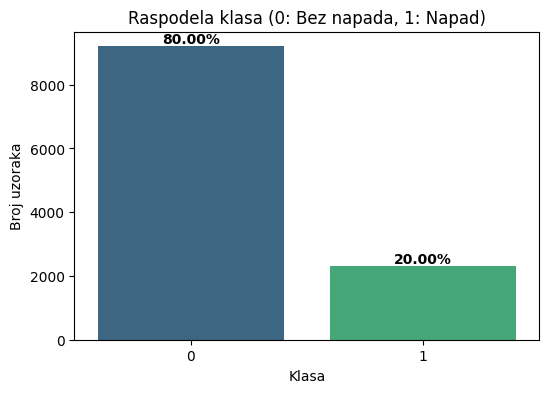

In [7]:
# Tabela i grafik

counts = y.value_counts()
percentages = y.value_counts(normalize=True) * 100

distribution_table = pd.DataFrame({
    'Broj uzoraka': counts,
    'Procenat (%)': percentages
})

print("Broj uzoraka po binarizovanim klasama (0: Bez napada, 1: Napad):\n")

print(distribution_table)


plt.figure(figsize=(6, 4))
sns.barplot(x=distribution_table.index, y=distribution_table['Broj uzoraka'], palette='viridis', hue=distribution_table.index, legend=False)

plt.title('Raspodela klasa (0: Bez napada, 1: Napad)')
plt.xlabel('Klasa')
plt.ylabel('Broj uzoraka')

for i, v in enumerate(counts):
    plt.text(i, v + 100, f'{percentages[i]:.2f}%', ha='center', fontweight='bold')

plt.show()

Svođenje na binarnu klasifikaciju dovodi do **nebalansiranog skupa podataka** (jer samo jedna od 5 klasa predstavlja napad).

## Grafik signala po klasama

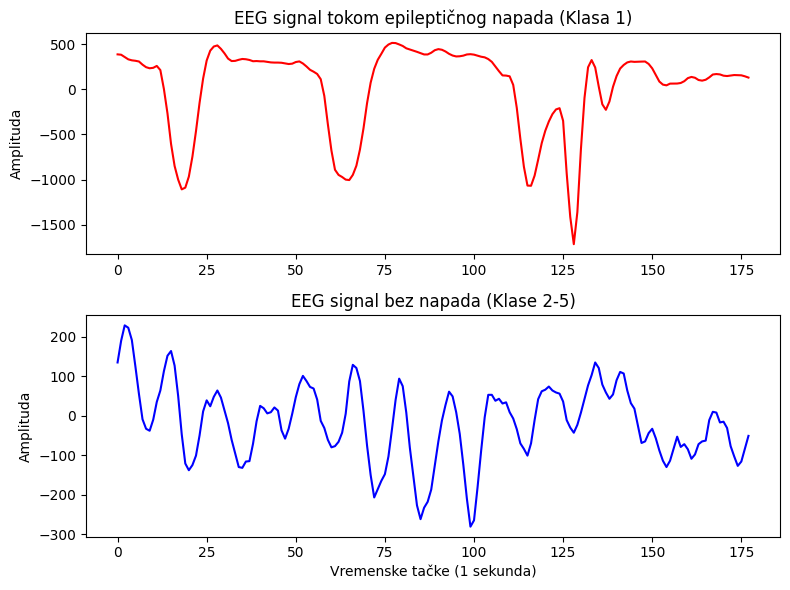

In [8]:
# Grafik signala po klasama

# Biramo po jedan primer za svaku situaciju
napad = df[df['y'] == 1].iloc[0, 1:179] # Prvi red gde je napad
bez_napada = df[df['y'] == 0].iloc[0, 1:179] # Prvi red gde nije napad

# Crtanje grafikona
plt.figure(figsize=(8, 6))

# Prvi podgrafik - Napad
plt.subplot(2, 1, 1)
plt.plot(napad.values, color='red')
plt.title('EEG signal tokom epileptičnog napada (Klasa 1)')
plt.ylabel('Amplituda')

# Drugi podgrafik - Bez napada
plt.subplot(2, 1, 2)
plt.plot(bez_napada.values, color='blue')
plt.title('EEG signal bez napada (Klase 2-5)')
plt.xlabel('Vremenske tačke (1 sekunda)')
plt.ylabel('Amplituda')

plt.tight_layout()
plt.show()


# Analiza standardne devijacije i varijanse

### Standardna devijacija signala po klasama

In [9]:
# Analiza std i var

std_values = X.std(axis=1)
var_values = X.var(axis=1)

signal_stats = pd.DataFrame()
signal_stats["std"] = std_values
signal_stats["var"] = var_values
signal_stats["class"] = y

table = signal_stats.groupby("class")[["std", "var"]].agg(["mean", "median", "min", "max"])
table.columns = ["_".join(col) for col in table.columns]
table = table.round(2)

print(table)

       std_mean  std_median  std_min  std_max   var_mean  var_median  var_min  \
class                                                                           
0         51.53       44.94    10.71   541.48    3828.04     2019.25   114.77   
1        303.47      277.41    51.50   810.40  115518.15    76958.39  2651.94   

         var_max  
class             
0      293205.20  
1      656749.44  


Uočavamo veću standardnu devijaciju kod klase '1' (napad).

# Nedostajuće vrednosti

In [10]:
# Nedostajuće vrednosti

print("Zbir nedostajućih vrednosti u svakoj koloni:\n")
df.isna().sum()

Zbir nedostajućih vrednosti u svakoj koloni:



Unnamed    0
X1         0
X2         0
X3         0
X4         0
          ..
X175       0
X176       0
X177       0
X178       0
y          0
Length: 180, dtype: int64

Zaključak: Nema nedostajućih vrednosti.

# Outliers

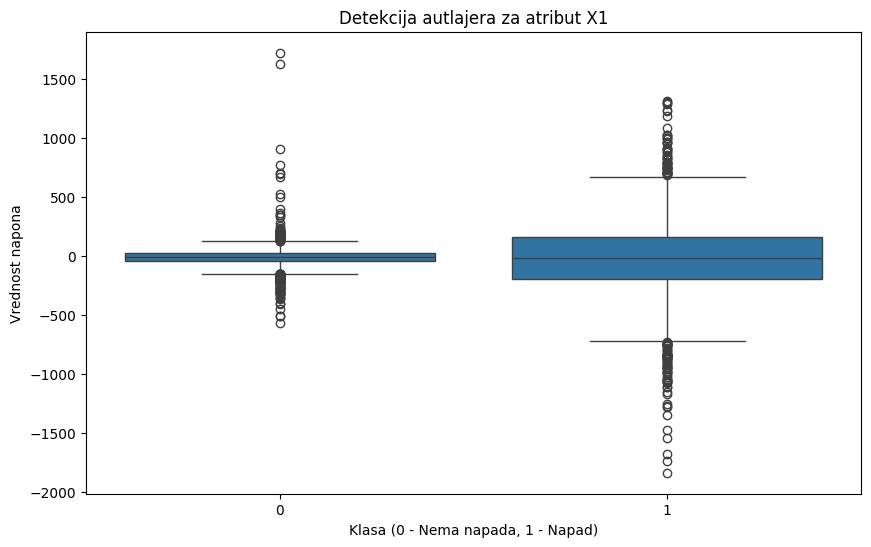

In [11]:
# Outliers

# Automatski uzimamo ime druge kolone (obično je to X1)
ime_kolone = df.columns[1]

plt.figure(figsize=(10, 6))
sns.boxplot(x='y', y=ime_kolone, data=df)

plt.title(f'Detekcija autlajera za atribut {ime_kolone}')
plt.xlabel('Klasa (0 - Nema napada, 1 - Napad)')
plt.ylabel('Vrednost napona')
plt.show()


# Korelaciona matrica

Biramo mali podskup kolona (npr. prvih 15 sekundi) jer bi 178x178 matrica bila nečitljiva

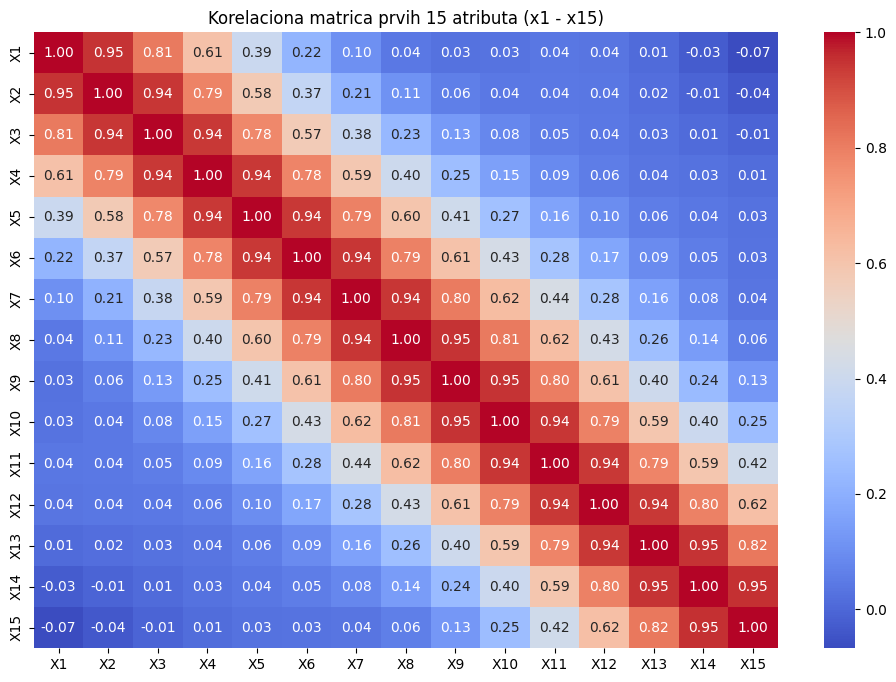

In [12]:
# Korelaciona matrica

# Biramo mali podskup kolona (npr. prvih 15 sekundi)
# jer bi 178x178 matrica bila nečitljiva
subset_columns = df.iloc[:, 1:16]

plt.figure(figsize=(12, 8))
# Računamo korelaciju
corr_matrix = subset_columns.corr()

# Crtamo toplotnu mapu (Heatmap)
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")

plt.title('Korelaciona matrica prvih 15 atributa (x1 - x15)')
plt.show()

# Analiza kolone 'Unnamed'

In [13]:
# Analiza kolone 'Unnamed'

df = pd.read_csv("../data.csv")
df['Unnamed'].head()



0    X21.V1.791
1    X15.V1.924
2       X8.V1.1
3     X16.V1.60
4     X20.V1.54
Name: Unnamed, dtype: str

Podaci u koloni se sastoje od tri segmenta odvojena '.'

In [14]:
# Oblik vrednosti u toj koloni:
# X[broj].V[broj].[broj]
# Tri segmenta odvojena '.'

parts = df['Unnamed'].str.split('.', expand=True)
parts.columns = ['part1', 'part2', 'part3']
df = pd.concat([df, parts], axis=1)

### Prvi segment
Format - X[broj]

In [15]:
# Prvi segment X[broj]

df['part1'].value_counts().sort_index()

part1
X1     500
X10    500
X11    500
X12    500
X13    500
X14    500
X15    500
X16    500
X17    500
X18    500
X19    500
X2     500
X20    500
X21    500
X22    500
X23    500
X3     500
X4     500
X5     500
X6     500
X7     500
X8     500
X9     500
Name: count, dtype: int64

In [16]:
df.groupby('part1').size().value_counts()


500    23
Name: count, dtype: int64

**Interpretacija prvog segmenta:**

X1 ... X23 su oznake segmenata
<br>
Svaki ispitanik 23 segmenta od po 1 sekundu, a ispitanika ima 500 <br> -> Zato za svaki segment postoji 500 vrednosti


## Drugi segment
Format - V[broj]

In [17]:
# Drugi segment V[broj]

df['part2'].value_counts().sort_index()

part2
V1     11408
V11       23
V12       23
V13       23
V14       23
Name: count, dtype: int64

In [18]:
pd.crosstab(df['part2'], df['y'])


y,1,2,3,4,5
part2,,,,,
V1,2277,2277,2277,2277,2300
V11,0,0,0,23,0
V12,0,0,23,0,0
V13,0,23,0,0,0
V14,23,0,0,0,0


**Interpretacija drugog segmenta**

Na osnovu raspodele vrednost iz segmenta 2 zakljucujemo da on ne donosi informativnost.
<br>
Mozemo pretpostaviti da proizilazi iz obeležavanja datoteka unutar sistema.

## Treći segment
Format - [broj]

In [19]:
# Treci segment [broj]

df['part3'].head()

0    791
1    924
2      1
3     60
4     54
Name: part3, dtype: str

In [20]:
df.groupby('part3').size()

part3
1      23
10     23
101    23
102    23
103    23
       ..
99     23
991    23
992    23
993    23
994    23
Length: 495, dtype: int64

**Interpretacija trećeg segmenta**

Segment 3 ima 495 (skoro 500) jedinstvenih vrednosti, svaka vrednost se ponavlja 23 puta u skupu.
<br>
Segment 3 identifikuje celokupan EEG zapis.



Primećujemo u određenom delu skupa fali treći segment.

In [21]:
# Koliko redova nema segment 3
num_missing = df['part3'].isna().sum()

# Ukupan broj redova
total_rows = len(df)

# Procenat
percent_missing = (num_missing / total_rows) * 100

print(f"Redova bez trećeg segmenta: {num_missing} / {total_rows} = {percent_missing:.2f}%")

Redova bez trećeg segmenta: 115 / 11500 = 1.00%


Treći segment fali u 1% skupa.

### Segment 3 postaje novo obeležje `recording_id`.

Kada bismo nasumično delili skup podataka (u train/test split), podaci iz jednog zapisa bi mogli da završe u razlicitim skupovima.
<br><br>
Ideja: Napraviti train/test split sa grupisanjem po `recording_id` tako da nema leakage-a.

U nastavku se formira nova kolona `recording_id`, na osnovu koje cemo podatke deliti u train i test skupove.
<br>
Uklanjaju se redovi koji nemaju segment 3.


In [22]:
df = pd.read_csv("../data.csv")

def extract_parts(unnamed):
    parts = unnamed.split(".")
    # Osiguravamo da part3 postoji, inače stavimo NaN
    part3 = int(parts[2]) if len(parts) == 3 else pd.NA
    return pd.Series({
        "part1": parts[0],   # X segment
        "part2": parts[1],   # V segment
        "part3": part3       # original recording ID
    })

df[['part1', 'part2', 'part3']] = df['Unnamed'].apply(extract_parts)

# Napravimo novu kolonu recording_id
df['recording_id'] = df['part3']

# Obrada redova gde ne postoji recording_id
# Uklanjanje, jer ih je mali broj (~115/11500)
df_clean = df.dropna(subset=['recording_id'])
df_clean = df_clean[df_clean['recording_id'].astype(str).str.strip() != ""]


C:\Users\38164\AppData\Local\Temp\ipykernel_7676\823009392.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[['part1', 'part2', 'part3']] = df['Unnamed'].apply(extract_parts)
C:\Users\38164\AppData\Local\Temp\ipykernel_7676\823009392.py:16: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['recording_id'] = df['part3']


## Priprema podataka za podelu u skupove za treniranje, test i validaciju

In [23]:
df_clean = df_clean.drop('Unnamed', axis=1)
df_clean = df_clean.drop('part1', axis=1)
df_clean = df_clean.drop('part2', axis=1)
df_clean = df_clean.drop('part3', axis=1)

In [24]:
# Podela na obeležja i ciljnju promenljivu

X = df_clean.drop('y', axis=1)
df_clean['y'] = df_clean['y'].apply(lambda x: 1 if x == 1 else 0)
y = df_clean['y']

Podaci sadrže i ``recording_id`` kako bi se uspešno delili prema EEG segmentima. ``recording_id`` će se ukloniti nakon podele.



# Train/Test/Validation split, bez data leakeage

Podela na trening (70%), validacioni (15%) i test skup (15%).

Segmenti jednog EEG napisa nalaze se isključivo u jednom od skupova.

In [26]:
# Train/test split koristeći GroupShuffleSplit

from sklearn.model_selection import GroupShuffleSplit

groups = df_clean['recording_id']

# Prvi split: 70% train, 30% temp (temp će biti kasnije podeljen na val/test)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, temp_idx = next(gss1.split(X, y, groups=groups))

X_train = X.iloc[train_idx]
X_train = X_train.drop('recording_id', axis=1) # VAZNO: uklanjanje recording_id
y_train = y.iloc[train_idx]

X_temp = X.iloc[temp_idx]
y_temp = y.iloc[temp_idx]

groups_temp = groups.iloc[temp_idx]  # zadržavamo grupu za drugi split

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=42)
val_idx, test_idx = next(gss2.split(X_temp, y_temp, groups=groups_temp))

X_val = X_temp.iloc[val_idx]
X_val = X_val.drop('recording_id', axis=1) # VAZNO: uklanjanje recording_id
y_val = y_temp.iloc[val_idx]

X_test = X_temp.iloc[test_idx]
X_test = X_test.drop('recording_id', axis=1) # VAZNO: uklanjanje recording_id
y_test = y_temp.iloc[test_idx]

# Rezultati
print("Broj trening uzoraka:", len(X_train))
print("Broj validation uzoraka:", len(X_val))
print("Broj test uzoraka:", len(X_test))



Broj trening uzoraka: 7958
Broj validation uzoraka: 1702
Broj test uzoraka: 1725


## Provera da je izbegnut data leakage

In [27]:
# Provera da li ima preklapanja recording_id između train i test
train_groups = set(groups.iloc[train_idx])
val_groups = set(groups_temp.iloc[val_idx])
test_groups = set(groups_temp.iloc[test_idx])

print("Preklapanje train/val:", train_groups & val_groups)
print("Preklapanje train/test:", train_groups & test_groups)
print("Preklapanje val/test:", val_groups & test_groups)
# set() znaci da je prazan skup - set=skup

print("\nBroj jedinstvenih recording_id u trening skupu:", len(train_groups))
print("Broj jedinstvenih recording_id u validacionom skupu:", len(val_groups))
print("Broj jedinstvenih recording_id u test skupu:", len(test_groups))



Preklapanje train/val: set()
Preklapanje train/test: set()
Preklapanje val/test: set()

Broj jedinstvenih recording_id u trening skupu: 346
Broj jedinstvenih recording_id u validacionom skupu: 74
Broj jedinstvenih recording_id u test skupu: 75


Svi segmenti koji imaju isti ``recording id`` se nalaze u jednom od tri skupa (skupovi su nepreklapajući).

# Standardizacija (normalizacija) podataka StandarScaler funkcijom

StandardScaler radi tako što izračunava srednju vrednost i standardnu devijaciju za svaku kolonu (feature). Ova faza se zove fit() i primenjuje se samo na trening skupu podataka. Potom, scaler koristi naučene statističke vrednosti iz trening skupa i vrši transformaciju sva tri skupa (trening, validacioni i test), uz pomoć funkcije transform().

Na ovaj način se takođe sprečava pojava curenja podataka iz trening skupa u validacioni i test skup tokom procesa standardizacije.

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

X_train = X_train_scaled.copy()
X_val = X_val_scaled.copy()
X_test = X_test_scaled.copy()

# Provera uspešnosti StandardScaler-a

In [29]:
feature_columns_before_scaling = X.drop('recording_id', axis=1).columns

selected_columns_for_stats = ['X1', 'X30', 'X60']

column_indices = {
    col: feature_columns_before_scaling.get_loc(col)
    for col in selected_columns_for_stats
}

scaled_datasets = {
    'X_train_scaled': X_train_scaled,
    'X_val_scaled': X_val_scaled,
    'X_test_scaled': X_test_scaled
}

for name, data_array in scaled_datasets.items():
    print(f"\n--- Statistika za skup {name} ---")
    for col_name, idx in column_indices.items():
        mean_val = data_array[:, idx].mean()
        std_val = data_array[:, idx].std()
        print(f"  {col_name}: Mean = {mean_val:.4f}, Std = {std_val:.4f}")


--- Statistika za skup X_train_scaled ---
  X1: Mean = 0.0000, Std = 1.0000
  X30: Mean = 0.0000, Std = 1.0000
  X60: Mean = 0.0000, Std = 1.0000

--- Statistika za skup X_val_scaled ---
  X1: Mean = -0.0168, Std = 1.2165
  X30: Mean = 0.0031, Std = 1.2482
  X60: Mean = 0.0374, Std = 1.2105

--- Statistika za skup X_test_scaled ---
  X1: Mean = -0.0158, Std = 0.9057
  X30: Mean = -0.0138, Std = 1.0223
  X60: Mean = -0.0245, Std = 0.9597


Trening skup ima srednju vrednost 0, a standardnu devijaciju 1, što je i očekivano jer se StandardScaler trenira upravo na ovim podacima da postigne te vrednosti.

Srednje vrednosti su blizu 0, a standardne devijacije blizu 1, za podatke iz validacionih i test skupova.
<br>
Razlike u vrednostima u odnosu na trening skup ukazuju na prirodne varijacije u distribuciji podataka između skupova.
<br>
Razlike se javljaju iz razloga što se na validacione i test skupove primenjuju parametri skaliranja naučeni isključivo iz trenirajućeg skupa, tako da je sprečen data leakage.

# Scalograms

Starting scalogram generation...



Generating train: 100%|██████████| 7958/7958 [00:32<00:00, 243.96it/s]


  Saved train:
    scalograms\X_train.npy  —  shape (7958, 1, 64, 178)
    scalograms\y_train.npy  —  shape (7958,)
    Class balance: 1472 seizure / 6486 non-seizure



Generating val: 100%|██████████| 1702/1702 [00:07<00:00, 223.62it/s]


  Saved val:
    scalograms\X_val.npy  —  shape (1702, 1, 64, 178)
    scalograms\y_val.npy  —  shape (1702,)
    Class balance: 414 seizure / 1288 non-seizure



Generating test: 100%|██████████| 1725/1725 [00:07<00:00, 221.89it/s]


  Saved test:
    scalograms\X_test.npy  —  shape (1725, 1, 64, 178)
    scalograms\y_test.npy  —  shape (1725,)
    Class balance: 391 seizure / 1334 non-seizure



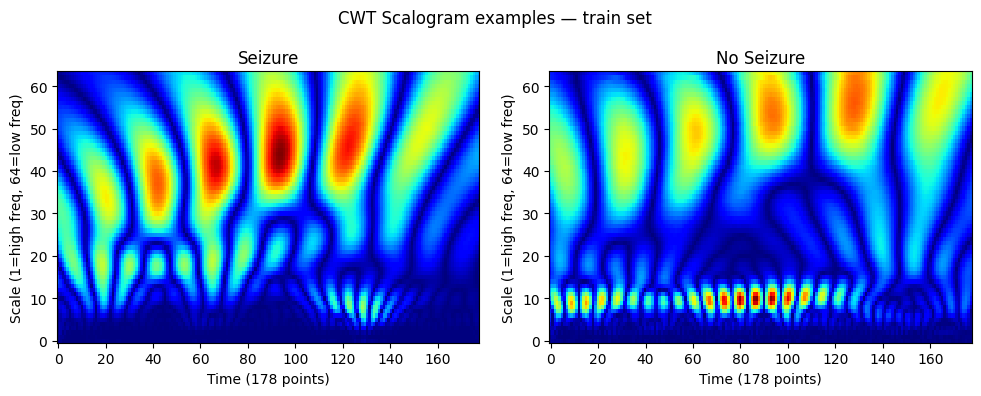

Done. Your scalogram files:
  X_test.npy           75.0 MB
  X_train.npy          345.8 MB
  X_val.npy            74.0 MB
  examples.png         0.1 MB
  y_test.npy           0.0 MB
  y_train.npy          0.1 MB
  y_val.npy            0.0 MB


In [31]:
import numpy as np
import pywt
import os
import matplotlib.pyplot as plt
from tqdm import tqdm

# ── CWT settings ──
SCALES  = np.arange(1, 65)   # 64 frequency scales
WAVELET = "morl"             # Morlet wavelet — best suited for EEG oscillations

# ── Output directory ──
SAVE_DIR = "scalograms"
os.makedirs(SAVE_DIR, exist_ok=True)


def signal_to_scalogram(signal):
    coefficients, _ = pywt.cwt(signal, SCALES, WAVELET)
    return np.abs(coefficients).astype(np.float32)


def generate_and_save(X, y, split_name):

    N = X.shape[0]
    scalograms = np.zeros((N, 1, 64, 178), dtype=np.float32)

    for i in tqdm(range(N), desc=f"Generating {split_name}"):
        scalograms[i, 0] = signal_to_scalogram(X[i])

    # Save
    x_path = os.path.join(SAVE_DIR, f"X_{split_name}.npy")
    y_path = os.path.join(SAVE_DIR, f"y_{split_name}.npy")

    np.save(x_path, scalograms)
    np.save(y_path, y)

    print(f"  Saved {split_name}:")
    print(f"    {x_path}  —  shape {scalograms.shape}")
    print(f"    {y_path}  —  shape {y.shape}")
    print(f"    Class balance: {y.sum()} seizure / {(y==0).sum()} non-seizure\n")


# ── Generate all three splits ──
print("Starting scalogram generation...\n")
generate_and_save(X_train, y_train, "train")
generate_and_save(X_val,   y_val,   "val")
generate_and_save(X_test,  y_test,  "test")


# ─────────────────────────────────────────────────────────────────────────────
# SANITY CHECK
# Plot one seizure and one non-seizure scalogram to visually confirm
# they look different before you commit to training.
# ─────────────────────────────────────────────────────────────────────────────

# Reload from disk to confirm saving worked correctly
X_train_s = np.load(os.path.join(SAVE_DIR, "X_train.npy"))
y_train_s = np.load(os.path.join(SAVE_DIR, "y_train.npy"))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, label, title in zip(axes, [1, 0], ["Seizure", "No Seizure"]):
    idx = np.where(y_train_s == label)[0][0]
    ax.imshow(
        X_train_s[idx, 0],
        aspect="auto",
        origin="lower",
        cmap="jet",
        interpolation="nearest"
    )
    ax.set_title(title)
    ax.set_xlabel("Time (178 points)")
    ax.set_ylabel("Scale (1=high freq, 64=low freq)")

plt.suptitle("CWT Scalogram examples — train set")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "examples.png"), dpi=100)
plt.show()

print("Done. Your scalogram files:")
for fname in sorted(os.listdir(SAVE_DIR)):
    fpath = os.path.join(SAVE_DIR, fname)
    size_mb = os.path.getsize(fpath) / (1024 ** 2)
    print(f"  {fname:<20} {size_mb:.1f} MB")

# Baseline CNN

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, confusion_matrix,
                             roc_curve, auc, roc_auc_score)
import seaborn as sns
import matplotlib.pyplot as plt
import os
import random


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — DEVICE
# ─────────────────────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — LOAD SCALOGRAMS
# ─────────────────────────────────────────────────────────────────────────────

X_train = np.load("scalograms/X_train.npy")
y_train = np.load("scalograms/y_train.npy")
X_val   = np.load("scalograms/X_val.npy")
y_val   = np.load("scalograms/y_val.npy")
X_test  = np.load("scalograms/X_test.npy")
y_test  = np.load("scalograms/y_test.npy")

print(f"\nLoaded scalograms:")
print(f"  Train : {X_train.shape}  --  {int(y_train.sum())} seizure / {int((y_train==0).sum())} non-seizure")
print(f"  Val   : {X_val.shape}  --  {int(y_val.sum())} seizure / {int((y_val==0).sum())} non-seizure")
print(f"  Test  : {X_test.shape}  --  {int(y_test.sum())} seizure / {int((y_test==0).sum())} non-seizure")

n_neg      = int((y_train == 0).sum())
n_pos      = int(y_train.sum())
POS_WEIGHT = n_neg / n_pos
print(f"\nCalculated pos_weight: {POS_WEIGHT:.2f}  ({n_neg} non-seizure / {n_pos} seizure)")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — DATASET
# ─────────────────────────────────────────────────────────────────────────────

class ScalogramDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — MODEL
# ─────────────────────────────────────────────────────────────────────────────

class BaselineCNN(nn.Module):
    def __init__(self, dropout):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 22, 256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 1)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — TRAINING FUNCTION (used during random search)
# ─────────────────────────────────────────────────────────────────────────────

def train_one_config(config, X_train, y_train, X_val, y_val, epochs=15):

    train_loader = DataLoader(
        ScalogramDataset(X_train, y_train),
        batch_size=config["batch_size"],
        shuffle=True
    )
    val_loader = DataLoader(
        ScalogramDataset(X_val, y_val),
        batch_size=config["batch_size"],
        shuffle=False
    )

    model     = BaselineCNN(dropout=config["dropout"]).to(device)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([config["pos_weight"]]).to(device)
    )
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )

    best_recall  = 0.0
    best_weights = None

    for epoch in range(epochs):

        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_X).squeeze(-1), batch_y)
            loss.backward()
            optimizer.step()

        model.eval()
        preds_all, true_all = [], []
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                probs = torch.sigmoid(model(batch_X).squeeze(-1)).cpu().numpy()
                preds_all.extend((probs > 0.5).astype(int))
                true_all.extend(batch_y.cpu().numpy().astype(int))

        val_recall = recall_score(true_all, preds_all, zero_division=0)

        if val_recall > best_recall:
            best_recall  = val_recall
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        scheduler.step(val_recall)

    return best_recall, best_weights


# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — RANDOM SEARCH WITH PATIENCE + MIN DELTA
# ─────────────────────────────────────────────────────────────────────────────

PARAM_SPACE = {
    "lr":         [0.0001, 0.001, 0.01],
    "batch_size": [32, 64, 128],
    "dropout":    [0.3, 0.5, 0.7],
    "pos_weight": [POS_WEIGHT * 0.75,
                   POS_WEIGHT,
                   POS_WEIGHT * 1.25],
}

N_TRIALS      = 20
SEARCH_EPOCHS = 15
PATIENCE      = 7
MIN_DELTA     = 0.01

print("\n" + "="*60)
print("RANDOM SEARCH  (optimising for Recall)")
print("="*60)
print(f"Max trials : {N_TRIALS}")
print(f"Patience   : {PATIENCE} trials")
print(f"Min delta  : {MIN_DELTA}")
print(f"\nParameter space:")
for k, v in PARAM_SPACE.items():
    print(f"  {k}: {v}")
print()

results            = []
best_recall_so_far = 0.0
no_improve_count   = 0

for trial in range(N_TRIALS):

    config = {k: random.choice(v) for k, v in PARAM_SPACE.items()}
    print(f"Trial {trial+1:02d}/{N_TRIALS} | Config: {config}")

    val_recall, best_weights = train_one_config(
        config, X_train, y_train, X_val, y_val,
        epochs=SEARCH_EPOCHS
    )

    results.append((val_recall, config, best_weights))

    improvement = val_recall - best_recall_so_far
    if improvement >= MIN_DELTA:
        best_recall_so_far = val_recall
        no_improve_count   = 0
        marker = f"  -> New best: {val_recall:.4f}  (improved by {improvement:.4f})"
    else:
        no_improve_count += 1
        marker = (f"  -> Recall: {val_recall:.4f}  "
                  f"(improvement {improvement:+.4f} < {MIN_DELTA} "
                  f"— no_improve: {no_improve_count}/{PATIENCE})")

    print(marker + "\n")

    if no_improve_count >= PATIENCE:
        print(f"Early stopping — no meaningful improvement for {PATIENCE} trials.\n")
        break

results.sort(key=lambda x: x[0], reverse=True)

print("="*60)
print("TOP 5 CONFIGURATIONS:")
print("="*60)
for i, (recall, config, _) in enumerate(results[:5]):
    print(f"  #{i+1}  Recall: {recall:.4f}  |  {config}")

best_recall_search, best_config, _ = results[0]
print(f"\nBest config  : {best_config}")
print(f"Best Recall  : {best_recall_search:.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 7 — RETRAIN BEST CONFIG
# ─────────────────────────────────────────────────────────────────────────────

FINAL_EPOCHS      = 30
RETRAIN_PATIENCE  = 5      # stop if no meaningful gain for this many epochs
RETRAIN_MIN_DELTA = 0.005  # minimum Recall improvement to count as real progress

print("\n" + "="*60)
print(f"RETRAINING BEST CONFIG FOR UP TO {FINAL_EPOCHS} EPOCHS")
print("="*60)

train_loader = DataLoader(
    ScalogramDataset(X_train, y_train),
    batch_size=best_config["batch_size"],
    shuffle=True
)
val_loader = DataLoader(
    ScalogramDataset(X_val, y_val),
    batch_size=best_config["batch_size"],
    shuffle=False
)
test_loader = DataLoader(
    ScalogramDataset(X_test, y_test),
    batch_size=best_config["batch_size"],
    shuffle=False
)

model     = BaselineCNN(dropout=best_config["dropout"]).to(device)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([best_config["pos_weight"]]).to(device)
)
optimizer = optim.Adam(model.parameters(), lr=best_config["lr"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

best_recall          = 0.0   # tracks the true best Recall — used to save weights
best_recall_patience = 0.0   # tracks Recall for patience — only moves on meaningful gains
best_weights         = None
no_improve_retrain   = 0
history              = {"train_loss": [], "val_loss": []}

for epoch in range(FINAL_EPOCHS):

    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(batch_X).squeeze(-1), batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss, preds_all, true_all = 0.0, [], []
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            out      = model(batch_X).squeeze(-1)
            val_loss += criterion(out, batch_y).item()
            probs     = torch.sigmoid(out).cpu().numpy()
            preds_all.extend((probs > 0.5).astype(int))
            true_all.extend(batch_y.cpu().numpy().astype(int))

    avg_train  = train_loss / len(train_loader)
    avg_val    = val_loss   / len(val_loader)
    val_recall = recall_score(true_all, preds_all, zero_division=0)

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)

    print(f"Epoch {epoch+1:02d}/{FINAL_EPOCHS} | "
          f"Train loss: {avg_train:.4f} | "
          f"Val loss: {avg_val:.4f}")

    # Always save the true best weights (any improvement counts)
    if val_recall > best_recall:
        best_recall  = val_recall
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}

    # Only reset patience counter on meaningful gains (>= RETRAIN_MIN_DELTA)
    if val_recall >= best_recall_patience + RETRAIN_MIN_DELTA:
        best_recall_patience = val_recall
        no_improve_retrain   = 0
        print(f"  -> New best ({val_recall:.4f})")
    else:
        no_improve_retrain += 1

    scheduler.step(val_recall)

    if no_improve_retrain >= RETRAIN_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} — "
              f"no meaningful improvement for {RETRAIN_PATIENCE} consecutive epochs.")
        break

model.load_state_dict(best_weights)
print(f"\nRetraining complete. Best Recall: {best_recall:.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 8 — TEST EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("TEST EVALUATION")
print("="*60)

model.eval()
probs_all, preds_all, true_all = [], [], []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        probs   = torch.sigmoid(model(batch_X).squeeze(-1)).cpu().numpy()
        probs_all.extend(probs.tolist())
        preds_all.extend((probs > 0.5).astype(int).tolist())
        true_all.extend(batch_y.numpy().astype(int).tolist())

precision = precision_score(true_all, preds_all, zero_division=0)
recall    = recall_score(true_all,    preds_all, zero_division=0)
f1        = f1_score(true_all,        preds_all, zero_division=0)
roc_auc   = roc_auc_score(true_all,   probs_all)

print(f"  Best config : {best_config}")
print(f"  Precision   : {precision:.3f}")
print(f"  Recall      : {recall:.3f}")
print(f"  F1-score    : {f1:.3f}")
print(f"  ROC-AUC     : {roc_auc:.3f}")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 9 — PLOTS
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs("plots", exist_ok=True)

# ── Plot 1: Train vs Val loss ──
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train loss", color="steelblue")
plt.plot(history["val_loss"],   label="Val loss",   color="darkorange", linestyle="--")
plt.title("Train vs Validation Loss — BaselineCNN")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("plots/baseline_loss_curves.png", dpi=100)
plt.show()

# ── Plot 2: Confusion matrix ──
cm = confusion_matrix(true_all, preds_all)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Purples",
            xticklabels=["No Seizure", "Seizure"],
            yticklabels=["No Seizure", "Seizure"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — BaselineCNN")
plt.tight_layout()
plt.savefig("plots/baseline_confusion_matrix.png", dpi=100)
plt.show()

# ── Plot 3: ROC curve ──
fpr, tpr, _ = roc_curve(true_all, probs_all)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Random classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — BaselineCNN")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("plots/baseline_roc_curve.png", dpi=100)
plt.show()

# ── Plot 4: Random search trial results ──
trial_recalls  = [r[0] for r in results]
sorted_recalls = sorted(trial_recalls, reverse=True)
n_ran          = len(results)

plt.figure(figsize=(8, 4))
plt.bar(range(1, n_ran + 1), sorted_recalls, color="purple", alpha=0.7)
plt.axhline(best_recall_search, color="red", linestyle="--",
            label=f"Best: {best_recall_search:.4f}")
plt.xlabel("Trial (sorted by Recall)")
plt.ylabel("Recall")
plt.title(f"Random Search — {n_ran} trials run (max {N_TRIALS})")
plt.legend()
plt.tight_layout()
plt.savefig("plots/random_search_results.png", dpi=100)
plt.show()

In [2]:
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

# Metrics computed on the TEST set (true_all, preds_all from the training cell above).
# Validation data was used only to select the best model weights — test data gives
# an unbiased final estimate of real-world performance.

precision   = precision_score(true_all, preds_all, zero_division=0)
recall      = recall_score(true_all, preds_all, zero_division=0)   # = Sensitivity
f1          = f1_score(true_all, preds_all, zero_division=0)

cm = confusion_matrix(true_all, preds_all)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)  # True Negative Rate

print("BaselineCNN — Test Set Metrics")
print("=" * 35)
print(f"  Precision   : {precision:.3f}")
print(f"  Recall      : {recall:.3f}  (= Sensitivity / True Positive Rate)")
print(f"  Specificity : {specificity:.3f}  (= True Negative Rate)")
print(f"  F1-score    : {f1:.3f}")
print()
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")


BaselineCNN — Test Set Metrics
  Precision   : 0.970
  Recall      : 0.910  (= Sensitivity / True Positive Rate)
  Specificity : 0.992  (= True Negative Rate)
  F1-score    : 0.939

  TP=356  FP=11  FN=35  TN=1323


# ResNet18

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from sklearn.metrics import (precision_score, recall_score,
                             f1_score, confusion_matrix,
                             roc_curve, roc_auc_score)
import seaborn as sns
import matplotlib.pyplot as plt
import os
import random


# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — DEVICE
# ─────────────────────────────────────────────────────────────────────────────

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — LOAD SCALOGRAMS
# ─────────────────────────────────────────────────────────────────────────────

X_train = np.load("scalograms/X_train.npy")
y_train = np.load("scalograms/y_train.npy")
X_val   = np.load("scalograms/X_val.npy")
y_val   = np.load("scalograms/y_val.npy")
X_test  = np.load("scalograms/X_test.npy")
y_test  = np.load("scalograms/y_test.npy")

print(f"\nLoaded scalograms:")
print(f"  Train : {X_train.shape}  --  {int(y_train.sum())} seizure / {int((y_train==0).sum())} non-seizure")
print(f"  Val   : {X_val.shape}  --  {int(y_val.sum())} seizure / {int((y_val==0).sum())} non-seizure")
print(f"  Test  : {X_test.shape}  --  {int(y_test.sum())} seizure / {int((y_test==0).sum())} non-seizure")

n_neg      = int((y_train == 0).sum())
n_pos      = int(y_train.sum())
POS_WEIGHT = n_neg / n_pos
print(f"\nCalculated pos_weight: {POS_WEIGHT:.2f}  ({n_neg} non-seizure / {n_pos} seizure)")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 3 — DATASET
# ─────────────────────────────────────────────────────────────────────────────

class ScalogramDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


# ─────────────────────────────────────────────────────────────────────────────
# STEP 4 — MODEL
# Dropout added before the final FC layer so it participates in random search.
# ─────────────────────────────────────────────────────────────────────────────

class ResNet18Classifier(nn.Module):
    def __init__(self, dropout=0.5):
        super().__init__()
        base       = models.resnet18(weights=None)
        base.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        base.fc    = nn.Sequential(nn.Dropout(dropout), nn.Linear(512, 1))
        self.model = base

    def forward(self, x):
        return self.model(x)


# ─────────────────────────────────────────────────────────────────────────────
# STEP 5 — TRAINING FUNCTION (used during random search)
# ─────────────────────────────────────────────────────────────────────────────

def train_one_config(config, X_train, y_train, X_val, y_val, epochs=15):

    train_loader = DataLoader(
        ScalogramDataset(X_train, y_train),
        batch_size=config["batch_size"],
        shuffle=True
    )
    val_loader = DataLoader(
        ScalogramDataset(X_val, y_val),
        batch_size=config["batch_size"],
        shuffle=False
    )

    model     = ResNet18Classifier(dropout=config["dropout"]).to(device)
    criterion = nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor([config["pos_weight"]]).to(device)
    )
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=3
    )

    best_recall  = 0.0
    best_weights = None

    for epoch in range(epochs):

        model.train()
        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(batch_X).squeeze(-1), batch_y)
            loss.backward()
            optimizer.step()

        model.eval()
        preds_all, true_all = [], []
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)
                probs = torch.sigmoid(model(batch_X).squeeze(-1)).cpu().numpy()
                preds_all.extend((probs > 0.5).astype(int))
                true_all.extend(batch_y.cpu().numpy().astype(int))

        val_recall = recall_score(true_all, preds_all, zero_division=0)

        if val_recall > best_recall:
            best_recall  = val_recall
            best_weights = {k: v.clone() for k, v in model.state_dict().items()}

        scheduler.step(val_recall)

    return best_recall, best_weights


# ─────────────────────────────────────────────────────────────────────────────
# STEP 6 — RANDOM SEARCH WITH PATIENCE + MIN DELTA
# ─────────────────────────────────────────────────────────────────────────────

PARAM_SPACE = {
    "lr":         [0.0001, 0.001, 0.01],
    "batch_size": [32, 64, 128],
    "dropout":    [0.3, 0.5, 0.7],
    "pos_weight": [POS_WEIGHT * 0.75,
                   POS_WEIGHT,
                   POS_WEIGHT * 1.25],
}

N_TRIALS      = 20
SEARCH_EPOCHS = 15
PATIENCE      = 7
MIN_DELTA     = 0.01

print("\n" + "="*60)
print("RANDOM SEARCH  (optimising for Recall)")
print("="*60)
print(f"Max trials : {N_TRIALS}")
print(f"Patience   : {PATIENCE} trials")
print(f"Min delta  : {MIN_DELTA}")
print(f"\nParameter space:")
for k, v in PARAM_SPACE.items():
    print(f"  {k}: {v}")
print()

results            = []
best_recall_so_far = 0.0
no_improve_count   = 0

for trial in range(N_TRIALS):

    config = {k: random.choice(v) for k, v in PARAM_SPACE.items()}
    print(f"Trial {trial+1:02d}/{N_TRIALS} | Config: {config}")

    val_recall, best_weights = train_one_config(
        config, X_train, y_train, X_val, y_val,
        epochs=SEARCH_EPOCHS
    )

    results.append((val_recall, config, best_weights))

    improvement = val_recall - best_recall_so_far
    if improvement >= MIN_DELTA:
        best_recall_so_far = val_recall
        no_improve_count   = 0
        marker = f"  -> New best: {val_recall:.4f}  (improved by {improvement:.4f})"
    else:
        no_improve_count += 1
        marker = (f"  -> Recall: {val_recall:.4f}  "
                  f"(improvement {improvement:+.4f} < {MIN_DELTA} "
                  f"— no_improve: {no_improve_count}/{PATIENCE})")

    print(marker + "\n")

    if no_improve_count >= PATIENCE:
        print(f"Early stopping — no meaningful improvement for {PATIENCE} trials.\n")
        break

results.sort(key=lambda x: x[0], reverse=True)

print("="*60)
print("TOP 5 CONFIGURATIONS:")
print("="*60)
for i, (recall, config, _) in enumerate(results[:5]):
    print(f"  #{i+1}  Recall: {recall:.4f}  |  {config}")

best_recall_search, best_config, _ = results[0]
print(f"\nBest config  : {best_config}")
print(f"Best Recall  : {best_recall_search:.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 7 — RETRAIN BEST CONFIG
# ─────────────────────────────────────────────────────────────────────────────

FINAL_EPOCHS      = 30
RETRAIN_PATIENCE  = 5      # stop if no meaningful gain for this many epochs
RETRAIN_MIN_DELTA = 0.005  # minimum Recall improvement to count as real progress

print("\n" + "="*60)
print(f"RETRAINING BEST CONFIG FOR UP TO {FINAL_EPOCHS} EPOCHS")
print("="*60)

train_loader = DataLoader(
    ScalogramDataset(X_train, y_train),
    batch_size=best_config["batch_size"],
    shuffle=True
)
val_loader = DataLoader(
    ScalogramDataset(X_val, y_val),
    batch_size=best_config["batch_size"],
    shuffle=False
)
test_loader = DataLoader(
    ScalogramDataset(X_test, y_test),
    batch_size=best_config["batch_size"],
    shuffle=False
)

model     = ResNet18Classifier(dropout=best_config["dropout"]).to(device)
criterion = nn.BCEWithLogitsLoss(
    pos_weight=torch.tensor([best_config["pos_weight"]]).to(device)
)
optimizer = optim.Adam(model.parameters(), lr=best_config["lr"])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="max", factor=0.5, patience=3
)

best_recall          = 0.0   # tracks the true best Recall — used to save weights
best_recall_patience = 0.0   # tracks Recall for patience — only moves on meaningful gains
best_weights         = None
no_improve_retrain   = 0
history              = {"train_loss": [], "val_loss": []}

for epoch in range(FINAL_EPOCHS):

    model.train()
    train_loss = 0.0
    for batch_X, batch_y in train_loader:
        batch_X, batch_y = batch_X.to(device), batch_y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(batch_X).squeeze(-1), batch_y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss, preds_all, true_all = 0.0, [], []
    with torch.no_grad():
        for batch_X, batch_y in val_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            out      = model(batch_X).squeeze(-1)
            val_loss += criterion(out, batch_y).item()
            probs     = torch.sigmoid(out).cpu().numpy()
            preds_all.extend((probs > 0.5).astype(int))
            true_all.extend(batch_y.cpu().numpy().astype(int))

    avg_train  = train_loss / len(train_loader)
    avg_val    = val_loss   / len(val_loader)
    val_recall = recall_score(true_all, preds_all, zero_division=0)

    history["train_loss"].append(avg_train)
    history["val_loss"].append(avg_val)

    print(f"Epoch {epoch+1:02d}/{FINAL_EPOCHS} | "
          f"Train loss: {avg_train:.4f} | "
          f"Val loss: {avg_val:.4f}")

    # Always save the true best weights (any improvement counts)
    if val_recall > best_recall:
        best_recall  = val_recall
        best_weights = {k: v.clone() for k, v in model.state_dict().items()}

    # Only reset patience counter on meaningful gains (>= RETRAIN_MIN_DELTA)
    if val_recall >= best_recall_patience + RETRAIN_MIN_DELTA:
        best_recall_patience = val_recall
        no_improve_retrain   = 0
        print(f"  -> New best ({val_recall:.4f})")
    else:
        no_improve_retrain += 1

    scheduler.step(val_recall)

    if no_improve_retrain >= RETRAIN_PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1} — "
              f"no meaningful improvement for {RETRAIN_PATIENCE} consecutive epochs.")
        break

model.load_state_dict(best_weights)
print(f"\nRetraining complete. Best Recall: {best_recall:.4f}")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 8 — TEST EVALUATION
# ─────────────────────────────────────────────────────────────────────────────

print("\n" + "="*60)
print("TEST EVALUATION")
print("="*60)

model.eval()
probs_all, preds_all, true_all = [], [], []

with torch.no_grad():
    for batch_X, batch_y in test_loader:
        batch_X = batch_X.to(device)
        probs   = torch.sigmoid(model(batch_X).squeeze(-1)).cpu().numpy()
        probs_all.extend(probs.tolist())
        preds_all.extend((probs > 0.5).astype(int).tolist())
        true_all.extend(batch_y.numpy().astype(int).tolist())

precision = precision_score(true_all, preds_all, zero_division=0)
recall    = recall_score(true_all,    preds_all, zero_division=0)
f1        = f1_score(true_all,        preds_all, zero_division=0)
roc_auc   = roc_auc_score(true_all,   probs_all)

cm_eval           = confusion_matrix(true_all, preds_all)
tn, fp, fn, tp    = cm_eval.ravel()
specificity       = tn / (tn + fp)

print(f"  Best config : {best_config}")
print()
print("ResNet18 — Test Set Metrics")
print("=" * 35)
print(f"  Precision   : {precision:.3f}")
print(f"  Recall      : {recall:.3f}  (= Sensitivity / True Positive Rate)")
print(f"  Specificity : {specificity:.3f}  (= True Negative Rate)")
print(f"  F1-score    : {f1:.3f}")
print(f"  ROC-AUC     : {roc_auc:.3f}")
print()
print(f"  TP={tp}  FP={fp}  FN={fn}  TN={tn}")


# ─────────────────────────────────────────────────────────────────────────────
# STEP 9 — PLOTS
# ─────────────────────────────────────────────────────────────────────────────

os.makedirs("plots", exist_ok=True)

# ── Plot 1: Train vs Val loss ──
plt.figure(figsize=(8, 4))
plt.plot(history["train_loss"], label="Train loss", color="steelblue")
plt.plot(history["val_loss"],   label="Val loss",   color="darkorange", linestyle="--")
plt.title("Train vs Validation Loss — ResNet18")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig("plots/resnet18_loss_curves.png", dpi=100)
plt.show()

# ── Plot 2: Confusion matrix ──
plt.figure(figsize=(5, 4))
sns.heatmap(cm_eval, annot=True, fmt="d", cmap="Purples",
            xticklabels=["No Seizure", "Seizure"],
            yticklabels=["No Seizure", "Seizure"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — ResNet18")
plt.tight_layout()
plt.savefig("plots/resnet18_confusion_matrix.png", dpi=100)
plt.show()

# ── Plot 3: ROC curve ──
fpr, tpr, _ = roc_curve(true_all, probs_all)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--", label="Random classifier")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — ResNet18")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("plots/resnet18_roc_curve.png", dpi=100)
plt.show()

# ── Plot 4: Random search trial results ──
trial_recalls  = [r[0] for r in results]
sorted_recalls = sorted(trial_recalls, reverse=True)
n_ran          = len(results)

plt.figure(figsize=(8, 4))
plt.bar(range(1, n_ran + 1), sorted_recalls, color="purple", alpha=0.7)
plt.axhline(best_recall_search, color="red", linestyle="--",
            label=f"Best: {best_recall_search:.4f}")
plt.xlabel("Trial (sorted by Recall)")
plt.ylabel("Recall")
plt.title(f"Random Search — {n_ran} trials run (max {N_TRIALS})")
plt.legend()
plt.tight_layout()
plt.savefig("plots/resnet18_random_search_results.png", dpi=100)
plt.show()